## Surface Fluxes Taylor Series Expansion
This looks at the taylor series expansion of variables that contribute to each individual flux.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import itertools
import xarray as xr
import scipy.optimize
from scipy.interpolate import CubicSpline

from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots, colored_line
from isca_tools.thesis.surface_energy_budget import get_param_dimensionless, get_temp_extrema_theory
from isca_tools.utils.constants import R
from isca_tools.thesis.mod_parcel_theory import get_temp_mod_parcel, get_scale_factor_theory_numerical2, \
    get_scale_factor_theory
from isca_tools.thesis.surface_flux_taylor import get_latent_heat, get_sensitivity_lh, reconstruct_lh, name_nl, \
    name_square, reconstruct_sh, reconstruct_lw, get_sensible_heat, get_lwup_sfc_net, get_temp_rad, get_sensitivity_sh, \
    get_sensitivity_lw
import inspect
import copy
import jobs.thesis_season.thesis_figs.utils as utils
from isca_tools.utils.xarray import update_dim_slice

warnings.filterwarnings('ignore')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
width = {'one_col': 3.2, 'two_col': 5.5}  # width in inches
im_sz = 1.5
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [3]:
# Load actual data for check flux calculations match simulated and to do example decomposition
ds_base = utils.load_ds(depth=20, reduced_evap=False).isel(
    lat=-1).squeeze()  # only use one latitude, highest so the biggest seasonal cycle as a test
ds_test = ds_base.isel(lon=np.random.randint(0, ds_base.lon.size - 1), time=slice(0,
                                                                                  360))  # choose the first year at a single longitude (different each time) as sanity check formulae work
ds = utils.get_annual_zonal_mean(ds_base)  # smoothed average version
ds['flux_net'] = ds.flux_lhe + ds.flux_t + ds.lwup_sfc - ds.lwdn_sfc  # compute net flux with smoothed variables

  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
temp_surf_anom = {'simulated': ds.temp_surf - ds.temp_surf.mean()}
surf_flux_up_params = utils.polyfit_phase_xr(temp_surf_anom['simulated'],
                                             ds.flux_net,
                                             deg=2,
                                             include_phase=True, include_fourier=True)
temp_surf_anom['approx'], _, _, var, _ = utils.get_temp_fourier_analytic_xr(ds.time, ds.swdn_sfc, ds.heat_capacity,
                                                                            surf_flux_up_params,
                                                                            n_harmonics=2)
# Compute shortwave radiation with just a single harmonic
sw_amp1 = float(var.sel(harmonic=1))
sw_amp2 = float(var.sel(harmonic=2))
sw_single_harmonic = utils.fourier_series_xr(ds.time, var * [1, 1, 0], var * 0, pad_coefs_phase=True)

In [5]:
def get_t1(flux_params=surf_flux_up_params,
           heat_capacity=ds.heat_capacity, extrema_ind=1, n_days_year=ds.time.size):
    # Returns time in days
    f = 1 / (n_days_year * utils.day_seconds)
    heat_capacity_eff = heat_capacity * (1 - flux_params.sel(deg='phase') / (2 * np.pi * f * heat_capacity))
    x = float(2 * np.pi * f * heat_capacity_eff / flux_params.sel(deg='1'))
    time_harmonic1 = np.arctan(x) / (2 * np.pi * f)
    if extrema_ind == 2:
        time_harmonic1 = time_harmonic1 + 1 / (2 * f)
    return time_harmonic1 / utils.day_seconds


def get_y(time=ds.time, heat_capacity=ds.heat_capacity, flux_params=surf_flux_up_params,
          extrema_ind=1, n_days_year=ds.time.size):
    # Returns y=sin(2\pi f\Delta) where \Delta=t_extrema - t_extrema_1
    # I.e. the time relative to first harmonic
    f = 1 / (n_days_year * utils.day_seconds)
    time_harmonic1 = get_t1(flux_params=flux_params, heat_capacity=heat_capacity, extrema_ind=extrema_ind,
                            n_days_year=n_days_year) * utils.day_seconds
    time_shift = time * utils.day_seconds - time_harmonic1  # shift in seconds
    y = np.sin(2 * np.pi * f * time_shift)
    # temp_spline = CubicSpline(np.append(time, time[-1]+1), np.append(temp, temp[0]), bc_type='periodic')
    return y

In [6]:
def sort_arrays_by_first(arr1, arr2):
    # Combine arr1 and arr2 into tuples
    combined = list(zip(arr1, arr2))

    # Sort the combined list based on arr1 (the first element of each tuple)
    sorted_combined = sorted(combined, key=lambda x: x[0])

    # Extract sorted arrays from sorted_combined
    sorted_arr1 = [item[0] for item in sorted_combined]
    sorted_arr2 = [item[1] for item in sorted_combined]

    return sorted_arr1, sorted_arr2

In [37]:
def get_extrema_theory(time=ds.time, swdn_sfc=ds.swdn_sfc, flux_params=surf_flux_up_params,
                       heat_capacity=ds.heat_capacity, harmonic_extrema_ind=1, n_days_year=ds.time.size,
                       approx: bool = False, approx_a_params: bool = True):
    # If approx=True then uses algebra for y_ex as linear sum of mechanisms
    # If approx_a_params=True, approximates a2 and a3 as linear sum of mechanisms
    # but then solves numerically fo y_ex
    # harmonic_extrema_ind==1 is winter and 2 is summer
    f = 1 / (n_days_year * utils.day_seconds)
    x0 = float(2 * np.pi * f * heat_capacity / flux_params.sel(deg='1'))
    var = utils.get_temp_fourier_analytic_xr(time, swdn_sfc, heat_capacity, surf_flux_up_params)
    x1 = float(np.tan(var[2].sel(harmonic=1)))
    x2 = float(np.tan(var[2].sel(harmonic=2)))
    sw_amp1 = float(var[3].sel(harmonic=1))
    sw_amp_ratio = float(var[3].sel(harmonic=2) / sw_amp1)
    lambda_const = float(flux_params.sel(deg='1'))
    lambda_cos = float(get_param_dimensionless(flux_params.sel(deg='cos'), sw_fourier_amp1=sw_amp1))
    lambda_sin = float(get_param_dimensionless(flux_params.sel(deg='sin'), sw_fourier_amp1=sw_amp1))
    lambda_sq = float(
        get_param_dimensionless(flux_params.sel(deg='2'), sw_fourier_amp1=sw_amp1, lambda_const=lambda_const))
    alpha_1 = lambda_sq / (sw_amp_ratio - lambda_cos) * (1 - x1 ** 2) / (1 + x1 ** 2) ** 2
    alpha_2 = lambda_sin / (sw_amp_ratio - lambda_cos) + 2 * lambda_sq / (sw_amp_ratio - lambda_cos) * x1 / (
            1 + x1 ** 2) ** 2
    # x2 = (2*x0 - alpha_2) / (1+2*x0*alpha_2)      # approx x2 neglects alpha1*alpha2 term

    # Step 1 of algebra
    # a_1 = float(var[1].sel(harmonic=1)) * [1, -1][harmonic_extrema_ind - 1]
    # a_2 = float(var[1].sel(harmonic=2) * np.cos(2*var[2].sel(harmonic=1)-var[2].sel(harmonic=2)))
    # a_3 = -float(var[1].sel(harmonic=2) * np.sin(2*var[2].sel(harmonic=1)-var[2].sel(harmonic=2)))
    # Step 2 of algebra
    # prefactor = float(var[1].sel(harmonic=2)/(1+x1**2)/np.sqrt(1+x2**2))
    a_1 = sw_amp1 / lambda_const / np.sqrt(1 + x1 ** 2) * [1, -1][harmonic_extrema_ind - 1]
    # a_2 = prefactor * (1 - x1**2 + 2*x1*x2)
    # a_3 = -2*prefactor * (2*x1 - x2 + x1**2 * x2)

    # Final step of algebra
    # Exact
    # prefactor = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 2 * x0 * x2) * (sw_amp_ratio - lambda_cos) * (1 - alpha_1)
    # prefactor_x2 = prefactor * x2

    # Approx
    sw_amp_ratio_mod = sw_amp_ratio - lambda_cos
    a_2 = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * (
            sw_amp_ratio_mod * (4 * x1 * x0 - x1 ** 2 + 1) - lambda_sin * 2 * (x0 * x1 ** 2 + x1 - x0) - lambda_sq)
    a_3 = -2 * sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * (
            sw_amp_ratio_mod * 2 * (x1 - x0 + x0 * x1 ** 2) + lambda_sin * (
            4 * x0 * x1 - x1 ** 2 + 1) + lambda_sq * 2 * x0)
    if approx:
        # prefactor = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0**2)**2 * \
        #             (sw_amp_ratio_mod - lambda_sq * (1-x1**2)/(1+x1**2)**2
        #              ) * (1+8*x0**2-2*x0*x2)        # approx prefactor after linear taylor series in x2
        prefactor = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * \
                    (sw_amp_ratio_mod + 2 * x0 * lambda_sin + (4 * x0 * x1 + x1 ** 2 - 1) / (
                            1 + x1 ** 2) ** 2 * lambda_sq)  # after also neglect nonlinear terms
        prefactor_x2 = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 4 * x0 ** 2) * \
                       (2 * x0 * sw_amp_ratio_mod - lambda_sin + 2 * (x0 * x1 ** 2 - x0 - x1) / (
                               1 + x1 ** 2) ** 2 * lambda_sq)
        lambda_ph = float(
            get_param_dimensionless(flux_params.sel(deg='phase'), heat_capacity=heat_capacity, n_year_days=n_days_year))
        ph_factor = 1 - lambda_ph
        y_extrema = 2 / np.sqrt(1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2) * (
                sw_amp_ratio_mod * 2 * x0 * (x0**2 * ph_factor ** 2 - lambda_ph) + lambda_sq * 2 * x0 +
                lambda_sin * ((3 - lambda_ph) * (lambda_ph + 1) * x0 + 1)
        )
        if harmonic_extrema_ind != 2:
            y_extrema *= -1
        y_extrema += 16 * x0 / (1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2) ** 2 * (
                (3 + lambda_ph) * (1 - lambda_ph) * x0 ** 2 + 1) * (
                             ph_factor * x0 ** 2 - lambda_ph) * sw_amp_ratio_mod ** 2
        y_extrema -= 16 * x0 / (1 + x0 ** 2 * ph_factor ** 2) / (
                1 + 4 * x0 ** 2) ** 2 * lambda_sq ** 2  # squared lambda_sq term
        # y_extrema += 16*x0/(1 + x0 ** 2 * ph_factor ** 2) / (1 + 4 * x0 ** 2)**2 * (2 * x1 * (2*x0-x1)-1) * lambda_sq*sw_amp_ratio_mod
    else:
        if not approx_a_params:
            # Actual exact values
            prefactor = sw_amp1 / lambda_const / (1 + x1 ** 2) / (1 + 2 * x0 * x2) * (sw_amp_ratio - lambda_cos) * (
                    1 - alpha_1)
            prefactor_x2 = prefactor * x2
            a_2 = prefactor * (1 - x1 ** 2) + 2 * x1 * prefactor_x2
            a_3 = -4 * prefactor * x1 - 2 * prefactor_x2 * (x1 ** 2 - 1)

    T_func = lambda y: a_1 * np.sqrt(1 - y ** 2) + a_2 * (1 - 2 * y ** 2) + a_3 * y * np.sqrt(1 - y ** 2)
    dT_dt_func = lambda y: (-a_1 * y - 4 * a_2 * y * np.sqrt(1 - y ** 2) + a_3 * (
            1 - 2 * y ** 2)) * 2 * np.pi * f * utils.day_seconds  # K/days

    if not approx:
        y_extrema = scipy.optimize.least_squares(dT_dt_func, 0, bounds=(-1, 1))['x'][0]
    return y_extrema, T_func, dT_dt_func


get_extrema_theory(approx=True, harmonic_extrema_ind=2)[0]

-0.302549959929242

In [10]:
# Sanity check that get same results from above func and that in isca_tools of extrema from different methods
for key in ['approx', 'numerical']:
    for i in range(1, 3):
        var = get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, sw_amp2,
                                      float(surf_flux_up_params.sel(deg='1')),
                                      float(surf_flux_up_params.sel(deg='phase')),
                                      float(surf_flux_up_params.sel(deg='2')),
                                      float(surf_flux_up_params.sel(deg='cos')),
                                      float(surf_flux_up_params.sel(deg='sin')), extrema_ind=i,
                                      numerical=key == 'numerical')
        if key == 'approx':
            var = float(var[1])
        else:
            var = float(var[1] + var[2]['nl_residual'])
        var2 = get_extrema_theory(approx=key == 'approx', harmonic_extrema_ind=i)[0]
        print(f"{key} | Extrema {i} | y = {var:.3f} | Error = {var - var2:.2g}")
        if np.abs(var - var2) > 0.01:
            raise ValueError('Inconsistent Calculations')
print('Success!')

approx | Extrema 1 | y = 0.444 | Error = -5.6e-17
approx | Extrema 2 | y = -0.303 | Error = 5.6e-17
numerical | Extrema 1 | y = 0.335 | Error = -1.4e-15
numerical | Extrema 2 | y = -0.280 | Error = 1.4e-15
Success!


In [11]:
get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, sw_amp2,
                        float(surf_flux_up_params.sel(deg='1')),
                        float(surf_flux_up_params.sel(deg='phase')),
                        float(surf_flux_up_params.sel(deg='2')),
                        float(surf_flux_up_params.sel(deg='cos')),
                        float(surf_flux_up_params.sel(deg='sin')), extrema_ind=1,
                        numerical=False)[2]

{'sw': 0.33690479523973726,
 'square': 0.0009568485404236705,
 'sin': 0.0005773195872864867,
 'cos': 0.03465045904253945,
 'nl_sw': 0.05799632276924204,
 'nl_square': -1.2047266245694464e-07,
 'nl_cos': 0.000613485154970379,
 'nl_sw_cos': 0.011929775029194905}

In [12]:
get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, sw_amp2,
                        float(surf_flux_up_params.sel(deg='1')),
                        float(surf_flux_up_params.sel(deg='phase')),
                        float(surf_flux_up_params.sel(deg='2')),
                        float(surf_flux_up_params.sel(deg='cos')),
                        float(surf_flux_up_params.sel(deg='sin')), extrema_ind=1,
                        numerical=True)[2]

{'sw': 0.3159538272283089,
 'square': 0.0009567263307155758,
 'cos': 0.03512272086797173,
 'sin': 0.0035812303137979554,
 'nl_sw_square': -0.0003954646612731594,
 'nl_sw_cos': -0.010980021290085906,
 'nl_sw_sin': -0.008649072547209202,
 'nl_square_cos': 3.581906817970437e-06,
 'nl_square_sin': -3.04088026172886e-05,
 'nl_cos_sin': -0.0010801915519542057,
 'nl_residual': 0.0007559513127912143}

### Derivative and temperature as function of $y$
The blue dashed and black solid lines should overlap exactly if `use_algebra=False` below as there is no approximation, just a shift in time coordinate. This seems to be the case here. If `use_algebra=True`, there is approximation but it seems to perform remarkably well.

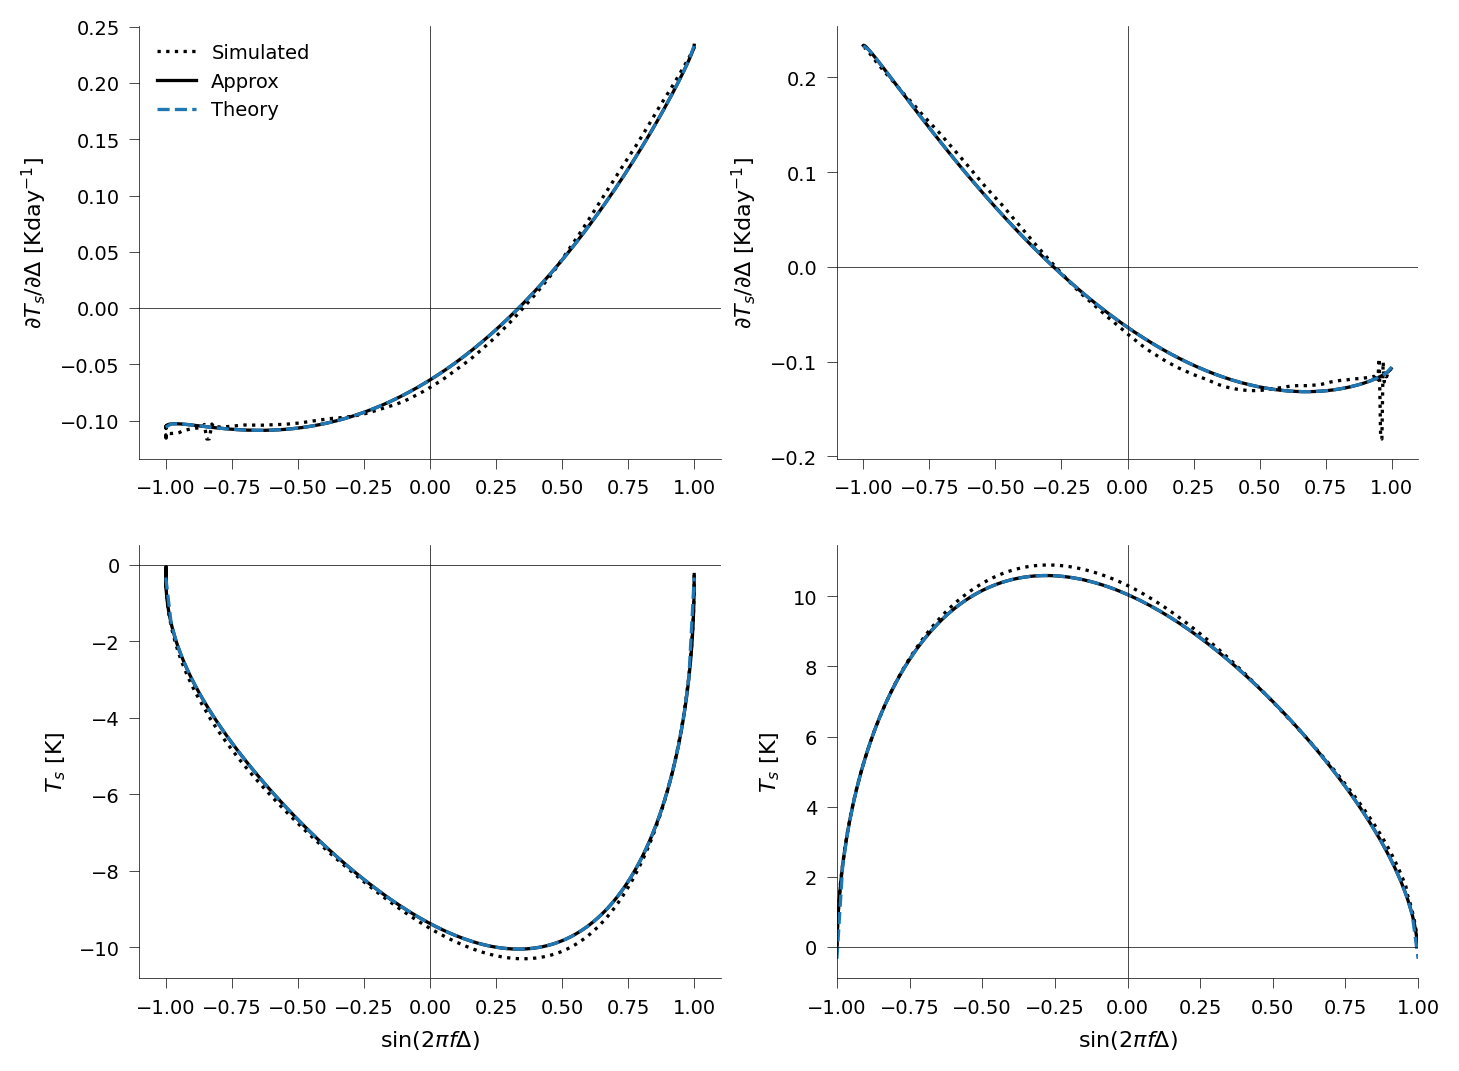

In [13]:
use_algebra = True
y_plot = np.linspace(-1, 1, 100)
linestyle_use = {'simulated': ':', 'approx': '-'}
fig, ax = plt.subplots(2, 2)
fig_resize(fig, width['two_col'] * 1.5)

for i in range(1, 3):
    # Plot simulated and direct fourier stuff
    ax[0, i - 1].set_ylabel('$\partial T_s/\partial \Delta$ [Kday$^{-1}$]')
    ax[1, i - 1].set_ylabel('$T_s$ [K]')
    spline_y = get_y(extrema_ind=i).values
    func_use = get_extrema_theory(harmonic_extrema_ind=i, approx=use_algebra)[1:]  # phase of 1st harmonic extrema
    if i == 2:
        use_ind = temp_surf_anom['simulated'] > 0
        # x1 = -1 * x1
    else:
        use_ind = temp_surf_anom['simulated'] < 0
    for key2 in temp_surf_anom:
        # use smoothed temp as use smoothed temp to find simulated extrema in time_extrema_temp
        spline_temp = CubicSpline(np.append(ds.time, ds.time[-1] + 1), np.append(temp_surf_anom[key2],
                                                                                 temp_surf_anom[key2][0]),
                                  bc_type='periodic')
        var2 = sort_arrays_by_first(spline_y[use_ind], spline_temp.derivative()(ds.time)[use_ind])
        ax[0, i - 1].plot(var2[0], var2[1], color='k', label=key2.capitalize(), linestyle=linestyle_use[key2])

        var2 = sort_arrays_by_first(spline_y[use_ind], spline_temp(ds.time)[use_ind])
        ax[1, i - 1].plot(var2[0], var2[1], color='k', label=key2, linestyle=linestyle_use[key2])
    ax[0, i - 1].plot(y_plot, func_use[1](y_plot), color='C0', label='Theory', linestyle='--')
    # For temperature, ensure the starting temperature of the integral is same as spline
    ax[1, i - 1].plot(y_plot, func_use[0](y_plot) - 0 * (func_use[0](float(var2[0][0])) + var2[1][0]), color='C0',
                      label='Theory', linestyle='--')

update_linewidth(fig)
for ax_use in ax.flatten():
    ax_use.axhline(0, color='k', lw=ax_linewidth)
    ax_use.axvline(0, color='k', lw=ax_linewidth)
ax[0, 0].legend()
ax[1, 0].set_xlabel('$\sin(2\pi f \Delta)$')
ax[1, 1].set_xlabel('$\sin(2\pi f \Delta)$')
ax[1, 1].set_xlim(-1, 1)
plt.show()

In [ ]:
plot_const_val = {}
plot_const_val['heat_capacity'] = get_heat_capacity(c_p_water, rho_water, layer_depth=5)
plot_const_val['lambda'] = 3
plot_const_val['F_1'] = -140
plot_const_val['sw'] = 1e-10    # small but non-zero, otherwise get divide by zero error
plot_const_val['phase'] = 0
plot_const_val['sq'] = 0
plot_const_val['cos'] = 0
plot_const_val['sin'] = 0
n_range_val = 21
plot_range_val = {'sw': np.linspace(-0.43, 0.43, n_range_val),
                  'phase': np.linspace(-0.8, 0.8, n_range_val),
                  'sq': np.linspace(-0.7, 0.7, n_range_val),
                  'cos': np.linspace(-0.05, 0.05, n_range_val),
                  'sin': np.linspace(-0.05, 0.05, n_range_val)}

extrema_time_range = {key: np.zeros((2, n_range_val)) for key in plot_range_val}
extrema_amp_range= {key: np.zeros((2, n_range_val)) for key in extrema_time_range}


for k in range(2):
    for i in range(n_range_val):
        for key2 in extrema_time_range:
            extrema_time_range[key2][k, i], extrema_amp_range[key2][k, i] = \
                get_extrema_theory(ds.time.to_numpy(), plot_const_val['F_1'],
                                   plot_const_val['F_1'] * (plot_range_val['sw'][i] if 'sw' in key2 else plot_const_val['sw']),
                                   plot_const_val['heat_capacity'], plot_const_val['lambda'],
                                   (plot_range_val['phase'][i] if 'phase' in key2 else plot_const_val['phase']) * plot_const_val['lambda'],
                                   (plot_range_val['sq'][i] if 'sq' in key2 else plot_const_val['sq']) *
                                   plot_const_val['lambda']**2 / plot_const_val['F_1'],
                                   (plot_range_val['cos'][i] if 'cos' in key2 else plot_const_val['cos']) * plot_const_val['F_1'],
                                   (plot_range_val['sin'][i] if 'sin' in key2 else plot_const_val['sin']) * plot_const_val['F_1'],
                                   harmonic_extrema_ind=k+1)[:2]

In [26]:
var_sw = np.linspace(0, 100, 51)
var_num = []
var_linear = []
var_nl = []
for var in var_sw:
    var_num.append(
        get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, var, float(surf_flux_up_params.sel(deg='1')),
                                0, 0, 0, 0, extrema_ind=2, numerical=True)[2]['sw'])
    var2 = get_temp_extrema_theory(float(ds.heat_capacity), sw_amp1, var, float(surf_flux_up_params.sel(deg='1')),
                                0, 0, 0, 0, extrema_ind=2, numerical=False)[2]
    var_linear.append(var2['sw'])
    var_nl.append(var2['nl_sw']+var2['sw'])

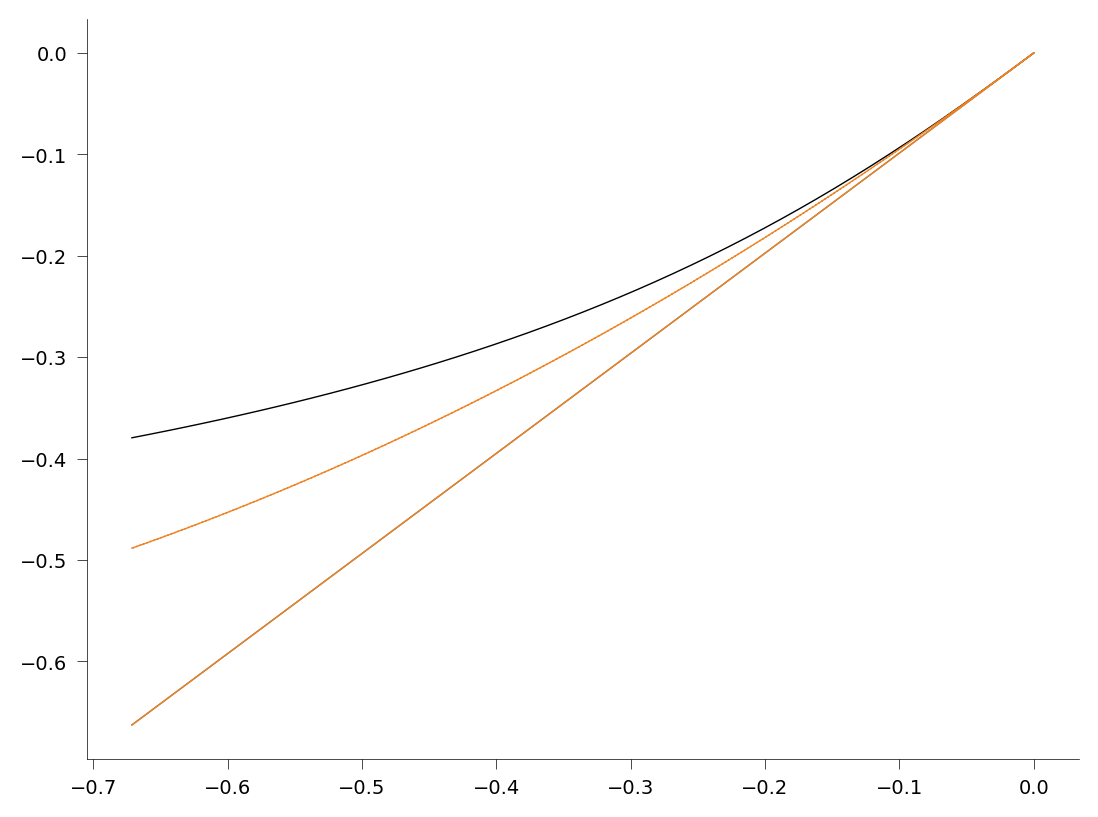

In [29]:
plt.plot(var_sw/sw_amp1, var_num, color='k')
plt.plot(var_sw/sw_amp1, var_linear, color='C0')
plt.plot(var_sw/sw_amp1, var_nl, color='C0', linestyle=':')
f = 1/(ds.time.size*utils.day_seconds)
x = 2*np.pi*f*float(ds.heat_capacity) / float(surf_flux_up_params.sel(deg='1'))
prefactor = 4*x**3 / (x**2+1)**0.5 / (4*x**2+1)
plt.plot(var_sw/sw_amp1, prefactor*var_sw/sw_amp1, color='C1')
prefactor_sq = 16*x**3*(3*x**2+1) / (x**2+1) / (4*x**2+1)**2
plt.plot(var_sw/sw_amp1, prefactor*var_sw/sw_amp1+prefactor_sq*(var_sw/sw_amp1)**2, color='C1')

In [95]:
def get_y_analytic(heat_capacity, param_linear, param_phase, param_sq=0, param_cos=0, param_sin=0,
                   n_days_year=ds.time.size,
                   extrema_ind=1):
    f = 1 / (n_days_year * utils.day_seconds)
    x0 = float(2 * np.pi * f * heat_capacity / param_linear)
    x1 = x0 * (1 - param_phase / (2 * np.pi * f * heat_capacity))
    coef_sin = -8 * x0 * (x1 - x0 + x1 ** 2 * x0) / np.sqrt(1 + x1 ** 2)
    coef_sin = -2 * (3 * x0 ** 2 + 1) / (4 * x0 ** 2 + 1) / np.sqrt(1 + x1 ** 2)
    if extrema_ind == 2:
        coef_sin = coef_sin * -1
    return coef_sin * param_sin

In [96]:
sin_coefs = np.linspace(-0.1, 0.1, 21)  # dimensionless versions
param_use = surf_flux_up_params.copy(deep=True) * [1, 0, 0, 0, 1, 1]  # set cos, sin, sq coefs to zero
y_sim = np.zeros((sin_coefs.size, 2))
y_approx = np.zeros((sin_coefs.size, 2))
for i in range(len(sin_coefs)):
    param_use = update_dim_slice(param_use.copy(deep=True), 'deg', 'sin', sin_coefs[i] * sw_amp1)
    # Use single harmonic so s2/s1=0
    temp_use = utils.get_temp_fourier_analytic_xr(ds.time, sw_single_harmonic, ds.heat_capacity,
                                                  param_use, n_harmonics=2)[0]
    var = list(utils.get_temp_extrema_numerical(ds.time.values, temp_use.values, order='min'))
    print(var)
    for j in range(2):
        y_sim[i, j] = get_y(var[j], float(ds.heat_capacity), param_use, j + 1)
        y_approx[i, j] = get_y_analytic(float(ds.heat_capacity), float(param_use.sel(deg='1')),
                                        float(param_use.sel(deg='phase')),
                                        param_sin=sin_coefs[i], extrema_ind=j + 1)

[59.12991264479802, 229.43856165370315, 32.0650302271563, 30.03528547648335]
[58.91316033722983, 229.79495741122784, 31.994138458007416, 30.08071686336647]
[58.539826871110854, 230.38605373842773, 31.875912395217835, 30.159633511661784]
[58.093784935366436, 231.05636792976523, 31.74078736390543, 30.25476862723776]
[57.645033761599365, 231.6937205355379, 31.611191170553933, 30.35111567252041]
[57.23492115296953, 232.24578302455245, 31.498011372957283, 30.43949154091379]
[56.78471070016012, 232.82064643917283, 31.37921891597183, 30.536660812653295]
[56.36247339532067, 233.3320705275012, 31.27272106965671, 30.627772926136107]
[55.87380157837832, 233.89289249907952, 31.155068489673486, 30.733034301495735]
[55.40185304513745, 234.40515427656206, 31.046835615817432, 30.834362368890073]
[54.91035014390951, 234.9103501439095, 30.93942868421709, 30.93942868421708]
[54.405154276562044, 235.40185304513744, 30.834362368890076, 31.046835615817432]
[53.88615084756348, 235.87984486929645, 30.73173440

In [97]:
y_approx

array([[ 0.08911583, -0.08911583],
       [ 0.08020425, -0.08020425],
       [ 0.07129266, -0.07129266],
       [ 0.06238108, -0.06238108],
       [ 0.0534695 , -0.0534695 ],
       [ 0.04455791, -0.04455791],
       [ 0.03564633, -0.03564633],
       [ 0.02673475, -0.02673475],
       [ 0.01782317, -0.01782317],
       [ 0.00891158, -0.00891158],
       [-0.        ,  0.        ],
       [-0.00891158,  0.00891158],
       [-0.01782317,  0.01782317],
       [-0.02673475,  0.02673475],
       [-0.03564633,  0.03564633],
       [-0.04455791,  0.04455791],
       [-0.0534695 ,  0.0534695 ],
       [-0.06238108,  0.06238108],
       [-0.07129266,  0.07129266],
       [-0.08020425,  0.08020425],
       [-0.08911583,  0.08911583]])

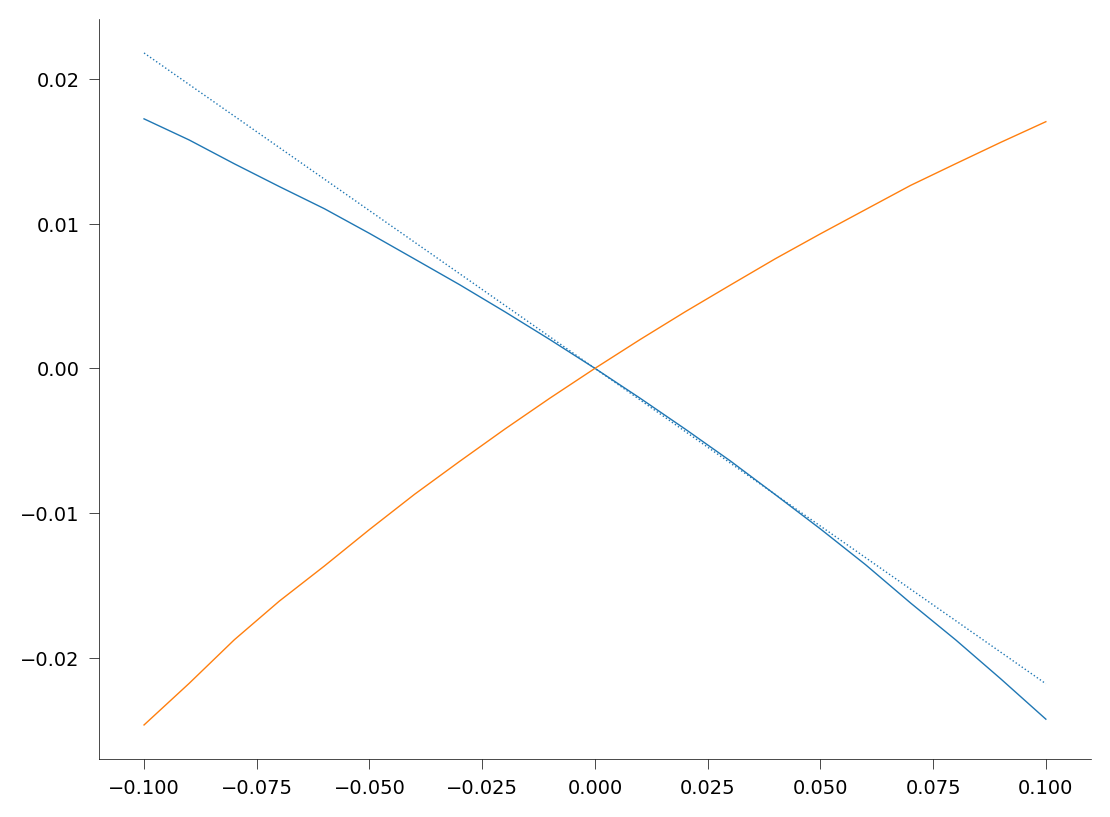

In [68]:
plt.plot(sin_coefs, y_sim[:, 0])
plt.plot(sin_coefs, y_sim[:, 1])
plt.plot(sin_coefs, y_approx[:, 0], color='C0', linestyle=':')

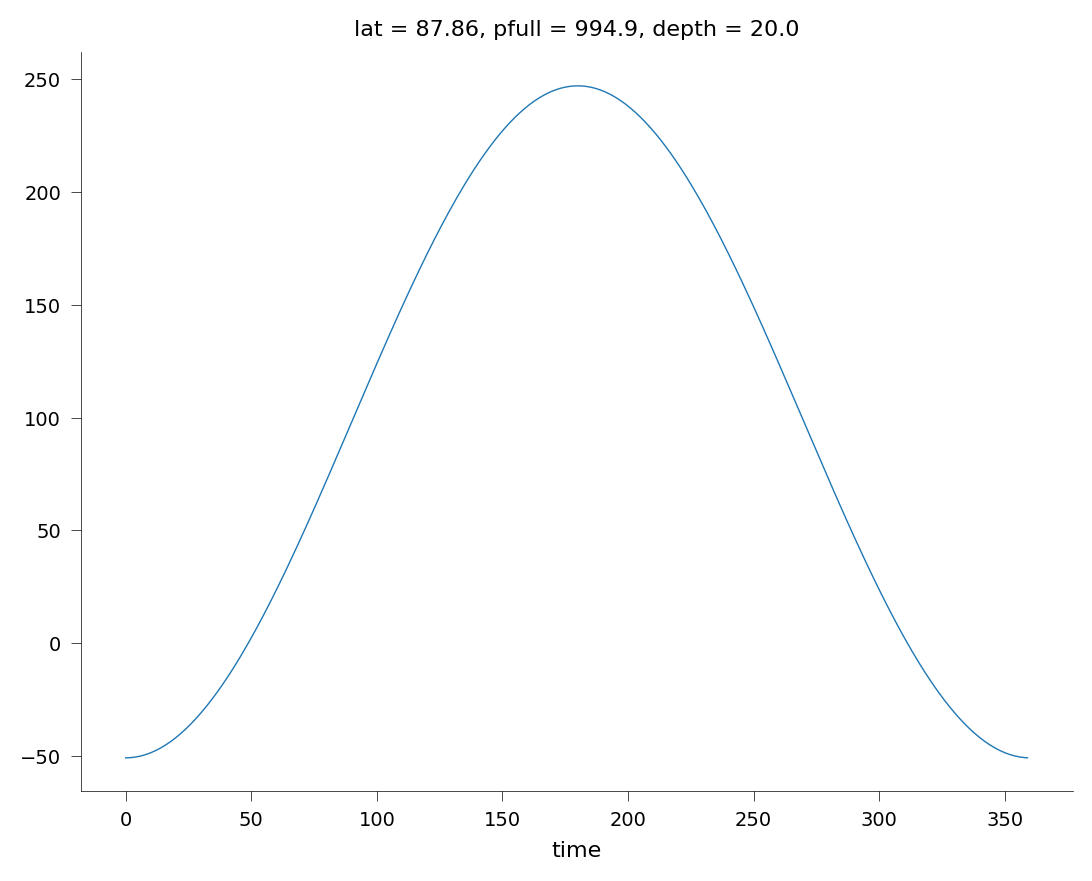

In [85]:
sw_single_harmonic.plot()

## Example Decomposition
Below I look at a smoothed dataset for a given latitude averaged over all longitudes and years. I plot the contribution from each variable to the variation of the flux with time over the year using the taylor series decomposition.

In [61]:
flux_ref = {}
flux_approx = {'lh': {'simulated': ds.flux_lhe,
                      'post_av': get_latent_heat(ds.temp_surf, ds.temp_diseqb, ds.rh_atm,
                                                 ds.w_atm, ds.drag_coef, ds.p_surf, ds.p_atm, ds.evap_prefactor)},
               'sh': {'simulated': ds.flux_t,
                      'post_av': get_sensible_heat(ds.temp_surf, ds.temp_diseqb, ds.w_atm, ds.drag_coef, ds.p_surf,
                                                   ds.p_atm)},
               'lw': {'simulated': ds.lw_sfc,
                      'post_av': get_lwup_sfc_net(ds.temp_surf, ds.temp_diseqb, ds.temp_diseqb_r, ds.odp_surf)}}

ds_av = ds.mean(dim='time', keep_attrs=True)
flux_cont = {'lh': {}, 'sh': {}, 'lw': {}}
for key in flux_cont:
    for key2 in ['theory', 'numerical']:
        flux_ref[key], flux_approx[key][key2], flux_approx[key][f"{key2}_nl"], flux_cont[key][key2] = \
            utils.reconstruct_flux_xr(ds, ds_av, flux_name=key, numerical=key2 == "numerical")
    for key2 in list(flux_approx[key].keys())[2:]:
        flux_approx[key][key2] += flux_ref[key]  # for all but simulated and post_av, need to add ref
    if key in ['lh', 'lw']:
        flux_cont[key]["theory"]["temp_surf"] += flux_cont[key]["theory"][
            name_square('temp_surf')]  # combine linear and square temp_surf cont

In [62]:
style_map = {'simulated': ('k', '-', 'Simulated'), 'post_av': ('k', ':', 'Manual'), 'theory': ('C0', '-', 'Theory'),
             'theory_nl': ('C0', '--', 'Theory - nl'), 'numerical': ('C1', '-', 'Numerical'),
             'numerical_nl': ('C1', '--', 'Numerical - nl')}

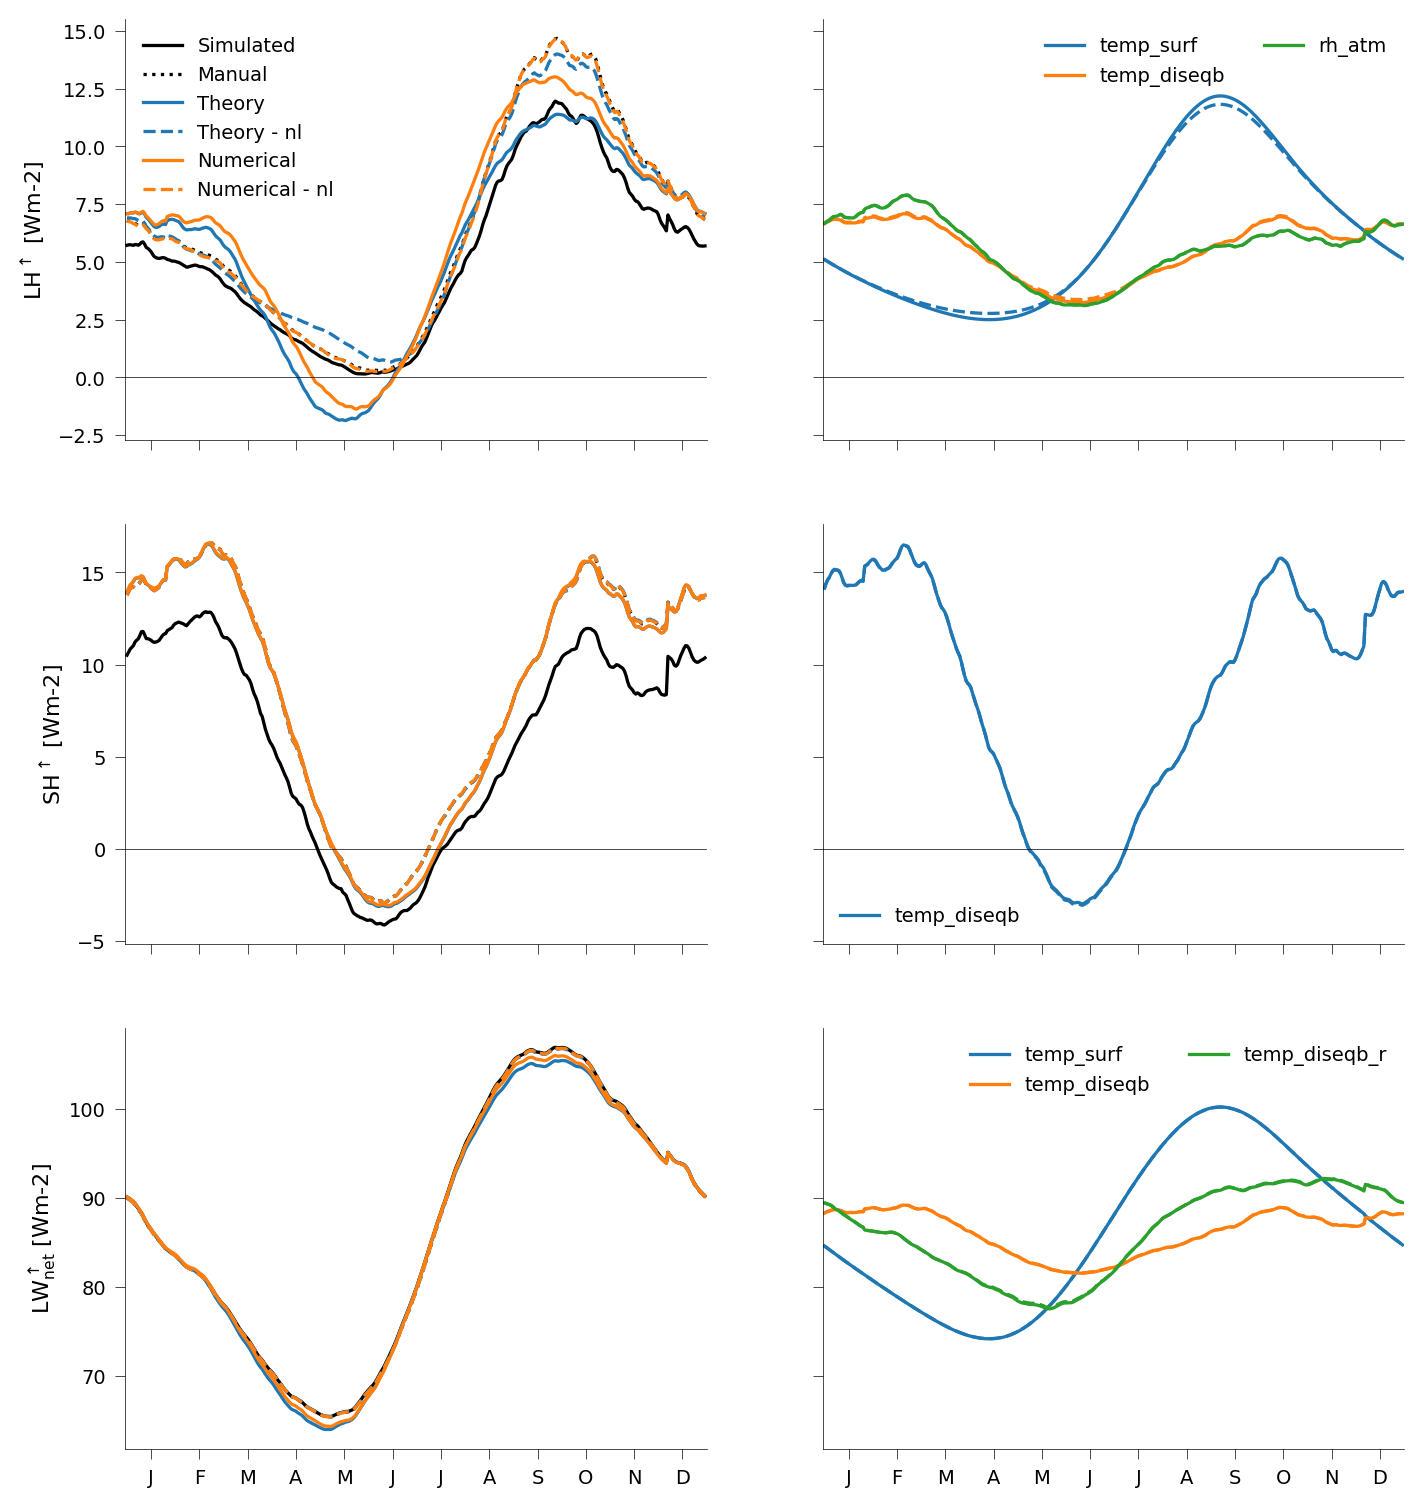

In [63]:
mech_thresh = 2  # Only mechanisms with Wm-2 greater than this are shown
fig, ax = plt.subplots(3, 2, sharex=True, sharey='row')
fig_resize(fig, width['two_col'] * 1.5)
for i, key in enumerate(flux_approx.keys()):
    ax[i, 0].set_ylabel(utils.style_map[key][2] + " [Wm-2]")
    for key2 in flux_approx[key]:
        ax[i, 0].plot(ds.time, flux_approx[key][key2], color=style_map[key2][0], linestyle=style_map[key2][1],
                      label=style_map[key2][2])
    j = 0
    for key2 in flux_cont[key]["numerical"]:
        if key2 == 'residual':
            continue
        if np.abs(flux_cont[key]["numerical"][key2]).max() > mech_thresh:
            ax[i, 1].plot(ds.time, flux_ref[key] + flux_cont[key]["numerical"][key2], label=key2, color=f"C{j}")
            if key2 in flux_cont[key]["theory"]:
                ax[i, 1].plot(ds.time, flux_ref[key] + flux_cont[key]["theory"][key2], color=f"C{j}", linestyle='--')
            j += 1
update_linewidth(fig)
ax[0, 0].legend()
ax[0, 0].set_xlim(-1, 360)
for i, ax_use in enumerate(ax.flatten()):
    if i % 2:
        ax_use.legend(ncol=2)
    if ax_use.get_ylim()[0] < 0:
        ax_use.axhline(0, color='k', lw=ax_linewidth)
ax[0, 0].set_xticks(*utils.month_ticks)
plt.show()

## Link to empirical fitting
Now that we see that the Taylor series approximation is decent, we would like to relate it to our empirical fitting.

We do this by fitting the same empirical fitting to each of the variables above (for non linear and square terms, we fit a separate fitting, don't compute from the individual fitting variables). Then we multiply these empirical variables with the taylor series coefficients to obtain the approximate contribution from each variable.

### Variable empirical fitting
First we do the empirical fitting for each of the variables, square terms, and non linear combinations separately.

In [64]:
ds_empirical_ref, var_params, ds_empirical, var_fit_error = utils.get_empirical_var_fit(ds[utils.style_map_var.keys()],
                                                                                        error_norm_dim=None)
ds_empirical_ref.attrs = ds_av.attrs
for key in ['sigma_atm', 'odp_surf', 'evap_prefactor']:
    ds_empirical_ref[key] = ds_av[key]

### Error in variable fitting
Below I plot the error in the fitting of each variable for the chosen latitude.

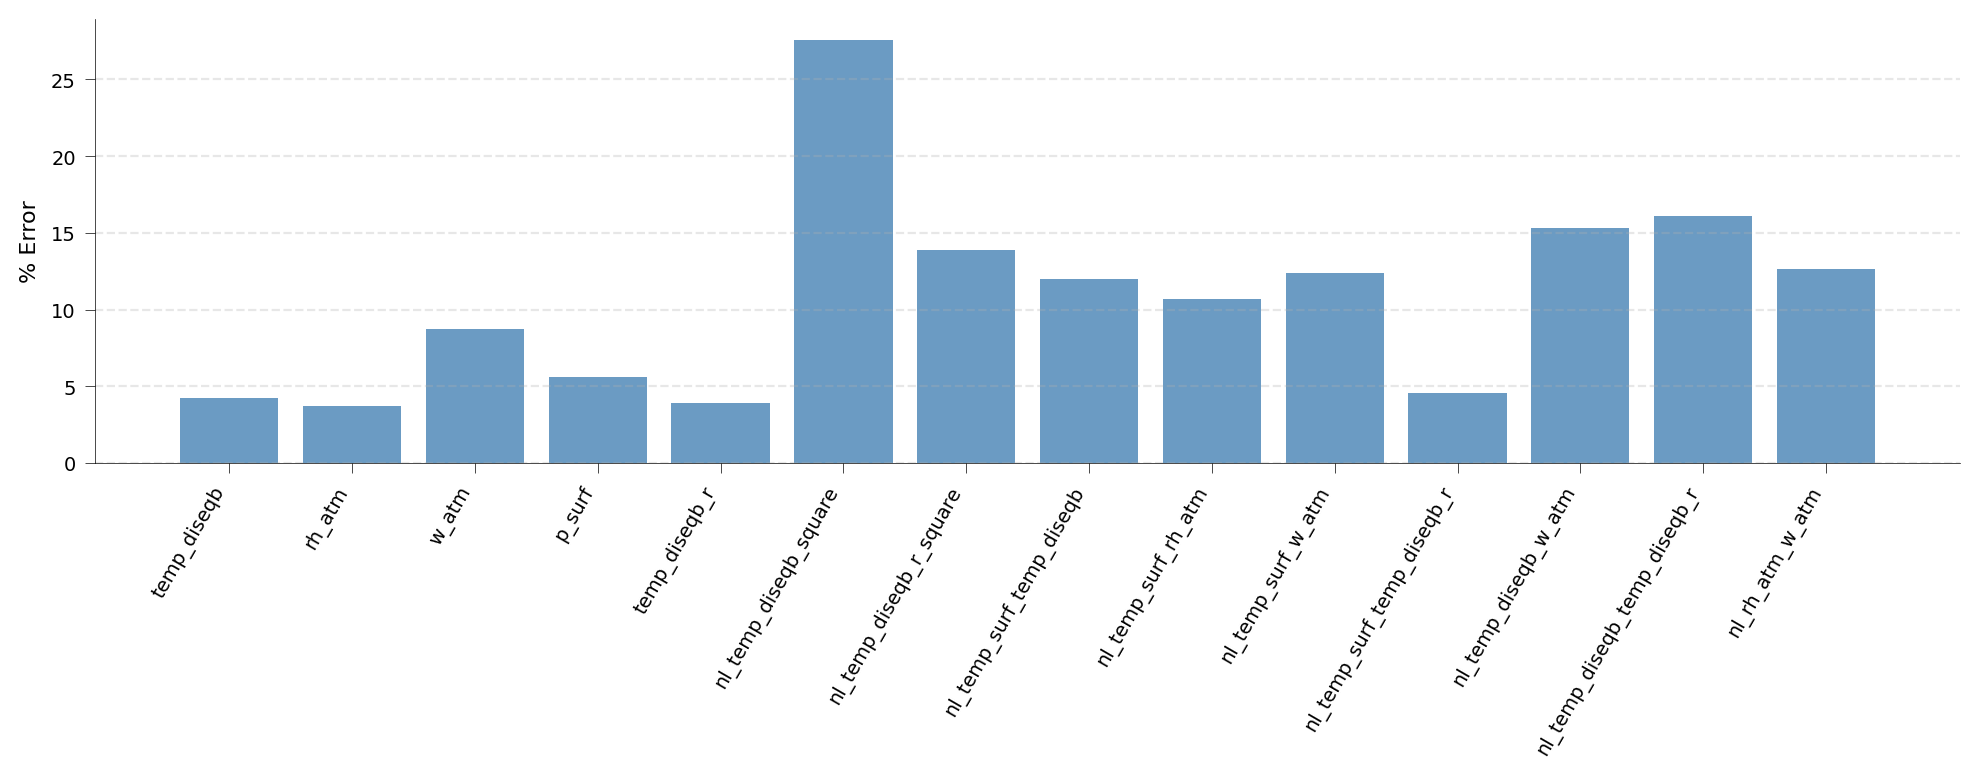

In [65]:
def plot_scalar_ds_bar(ds, var_ignore=None, ax=None, *, rotation=60):
    """Plot a single bar chart of scalar Dataset values (key -> value).

    Designed for the case in your screenshot where each `ds.data_vars[name]` is
    0D (a single number). Variables in `var_ignore` are skipped.

    Args:
        ds: xarray.Dataset. Expected to contain (mostly) 0D data variables.
        var_ignore: List of variable names to exclude.
        ax: Optional matplotlib Axes to draw on. If None, a new figure/axes is created.
        rotation: Rotation angle for x tick labels (degrees).

    Returns:
        fig: matplotlib Figure.
        ax: matplotlib Axes.
    """
    if var_ignore is None:
        var_ignore = []

    keys = [k for k in ds.data_vars.keys() if k not in set(var_ignore)]
    if len(keys) == 0:
        raise ValueError("No variables left to plot after applying var_ignore.")

    # Extract scalar values (works for 0D arrays; also handles size==1 arrays).
    vals = []
    kept_keys = []
    for k in keys:
        da = ds[k]
        if da.size != 1:
            # If you truly only want scalars, skip non-scalars explicitly.
            continue
        kept_keys.append(k)
        vals.append(float(da.values.reshape(-1)[0]))

    if len(kept_keys) == 0:
        raise ValueError("No scalar (size==1) variables found to plot.")

    x = np.arange(len(kept_keys))

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(10, 0.35 * len(kept_keys)), 4))
    else:
        fig = ax.figure

    ax.bar(x, vals, color="steelblue", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(kept_keys, rotation=rotation, ha="right")
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    fig.tight_layout()

    return fig, ax


var_ignore = [key for key in var_fit_error if "_p_surf" in key]  # or whatever you want to omit
var_ignore += [name_square('rh_atm'), name_square('w_atm')]  # never see these terms
for key in var_fit_error:
    if "nl" in key and "temp_diseqb_r" in key and (("w_atm" in key) or ("rh_atm" in key)):
        # These never come up
        var_ignore.append(key)
fig, ax = plot_scalar_ds_bar(var_fit_error, var_ignore=var_ignore)
ax.set_ylabel('% Error')
plt.show()


In [66]:
def get_var_sim(key):
    # Function to get simulated value of the variable indicated by key
    if 'square' in key:
        key2 = key.replace('nl_', '').replace('_square', '')
        var = (ds[key2] - ds_empirical_ref[key2]) ** 2
    elif 'nl' in key:
        var = None
        for var1, var2 in itertools.combinations(
                ["temp_surf", "temp_diseqb", "rh_atm", "w_atm", "p_surf", "temp_diseqb_r"], 2):
            if key == name_nl(var1, var2):
                var = (ds[var1] - ds_empirical_ref[var1]) * (ds[var2] - ds_empirical_ref[var2])
                break
        if var is None:
            raise ValueError(f'No found {key}')
    else:
        var = ds[key]
    return var

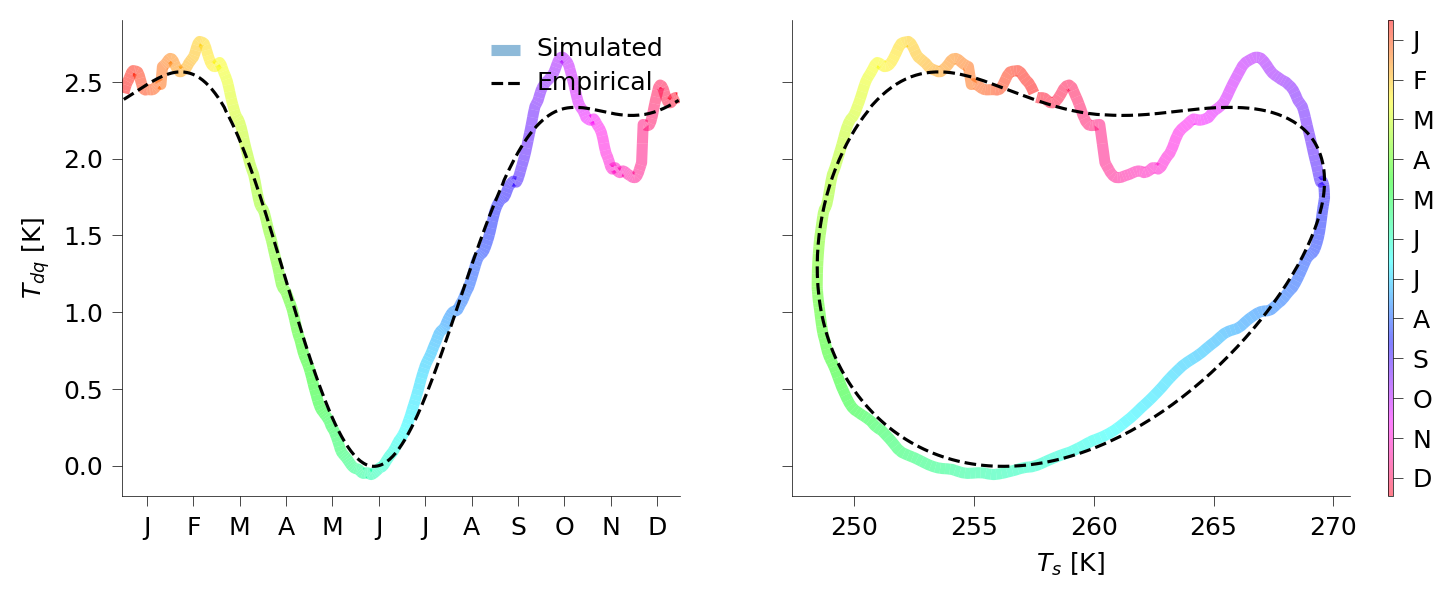

Fitting Error: 4.2%


In [67]:
key = 'nl_temp_diseqb_rh_atm'
key = 'temp_diseqb'
var = get_var_sim(key)
fig, ax = plt.subplots(1, 2, sharex=False, sharey=True)
fig_resize(fig, width['two_col'] * 1.5)
for i in range(len(ax)):
    im = colored_line(ds.time if i == 0 else ds.temp_surf, var, c=ds.time,
                      ax=ax[i], cmap='hsv', label='Simulated', lw=4, alpha=0.5)
ax[0].plot(ds.time, ds_empirical[key], color='k', linestyle='--', label='Empirical')
ax[1].plot(ds.temp_surf, ds_empirical[key], color='k', linestyle='--', label='Empirical')
cbar = fig.colorbar(im, ax=ax.ravel().tolist() if len(ax) > 1 else ax[0], aspect=100, pad=0.03, fraction=0.01)
cbar.ax.invert_yaxis()
cbar.ax.set_yticks(*utils.month_ticks)
update_linewidth(fig)
ax[0].legend(handlelength=utils.leg_handlelength)
try:
    ax[0].set_ylabel(f"{utils.style_map_var[key][2]} [{utils.style_map_var[key][3]}]")
except KeyError:
    ax[0].set_ylabel(key)
ax[1].set_xlabel(f"{utils.style_map_var['temp_surf'][2]} [{utils.style_map_var['temp_surf'][3]}]")
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_xlim(utils.ax_lims_time)
update_fontsize(fig)
plt.show()
print(f"Fitting Error: {var_fit_error[key]:.1f}%")

### Obtaining Flux Estimates
With these empirical variables, we multiply them by the relevant taylor series coefficient and sum them up. This is given by the blue dashed line below, which is a good match to the blue line using the actual variables.

To link it to the empirical fitting, we compute the overall empirical fitting parameters by summing up the individual contributions from each variable. Using these summed empirical fitting parameters, we do the empirical fitting. This is shown by the dashed orange line below, and compared to the vanilla empirical fitting in solid orange.

It is clear that the dashed orange line is a compromise between the taylor series and direct empirical fitting.

**Important point** is that sensitivity factors not calculated with mean value of each variable, but the empirical value of the variable with mean surface temperature, and all empirical constants set to 0 i.e. the deg=0 coefficient from the `polyfit` fitting. This is so as to match the form of the flux equation expected both from the taylor series and empirical fitting.

In [22]:
# Get sensitivity parameters i.e. taylor series coefficients for each variable and non linear term
# In taylor series expansion, expand about temp_surf_mean and all empirical fitting params set to zero
# This differs from the average of the variable if deg=2
# Important as affects the values used in gamma
ds_ref = ds_empirical_ref.copy(deep=True)
# ds_ref = ds_av.copy(deep=True)
flux_gamma = {key: utils.get_flux_sensitivity(ds_ref, key) for key in flux_cont}

In [23]:
# Get empirical param breakdown from contribution of each variable
flux_empirical_params = {}
for key2 in flux_cont:
    var_keep = [var for var in var_params if var in flux_gamma[key2]]
    flux_empirical_params[key2] = var_params[var_keep].copy(deep=True)
    for key in flux_gamma[key2]:
        if ('drag_coef' in key) or ('odp_surf' in key) or ('evap_prefactor' in key):
            # These variables constant in this case
            continue
        elif key in var_params:
            # Linear contribution from variable is just the lambda, lambda_cos, lambda_sin multiplied by the taylor coef
            flux_empirical_params[key2][key] *= flux_gamma[key2][key]
        elif key == 'temp_surf':
            flux_empirical_params[key2][key] = flux_empirical_params[key2]['temp_diseqb'] * 0  # initialize
            # Set temp surf values to exactly the taylor coefs
            flux_empirical_params[key2] = update_dim_slice(flux_empirical_params[key2], "deg", "1",
                                                           flux_gamma[key2][key], key)
            if name_square(key) in flux_gamma[key2]:
                flux_empirical_params[key2] = update_dim_slice(flux_empirical_params[key2], "deg", "2",
                                                               flux_gamma[key2][name_square(key)], key)
    flux_empirical_params[key2]['sum'] = flux_empirical_params[key2].to_array().sum("variable")
    for key in flux_empirical_params[key2]:
        # Make explicit that we did not compute the 0th harmonic coef here
        flux_empirical_params[key2] = update_dim_slice(flux_empirical_params[key2], 'deg', '0', 0, key)

In [24]:
# Actual fitting best possible to the post averaged variable computation of fluxes
for key2 in flux_empirical_params:
    flux_empirical_params[key2]['actual'] = utils.polyfit_phase_xr(ds.temp_surf - ds_av.temp_surf,
                                                                   flux_approx[key2]['post_av'], deg=2,
                                                                   include_phase=True, include_fourier=True)

In [25]:
# Get new estimates of fluxes
ds_empirical['temp_surf'] = ds.temp_surf
for key in flux_cont:
    # Use empirical fit to each variable, reconstruct using taylor series coefs
    # var is the reference value of the flux in the taylor series expansion calculated from ds_ref
    # Differs from ref calc from ds_av - important
    var, _, flux_approx[key]["taylor_empirical_vars"] = \
        utils.reconstruct_flux_xr(ds_empirical, ds_ref, flux_name=key, numerical=False)[:3]
    flux_approx[key]["taylor_empirical_vars"] += var  # for all but simulated and post_av, need to add ref
    # Using empirical fitting regardless of taylor coefs, find fit
    flux_approx[key]["empirical"] = utils.polyval_phase_xr(flux_empirical_params[key]['actual'],
                                                           ds.temp_surf - ds_av.temp_surf)
    # Using empirical fitting where params are sum of params fit to individual variables multiplied by taylor series coefs
    flux_approx[key]["empirical_from_taylor_params"] = utils.polyval_phase_xr(flux_empirical_params[key]['sum'],
                                                                              ds.temp_surf - ds_av.temp_surf) + var

In [26]:
style_map_approx = {'post_av': ('k', '-', 'Simulated'), 'theory_nl': ('C0', '-', 'Taylor'),
                    'taylor_empirical_vars': ('C0', '--', 'Taylor (fit vars)'),
                    'empirical': ('C1', '-', 'Empirical'),
                    'empirical_from_taylor_params': ('C1', '--', 'Empirical (fit vars)')}

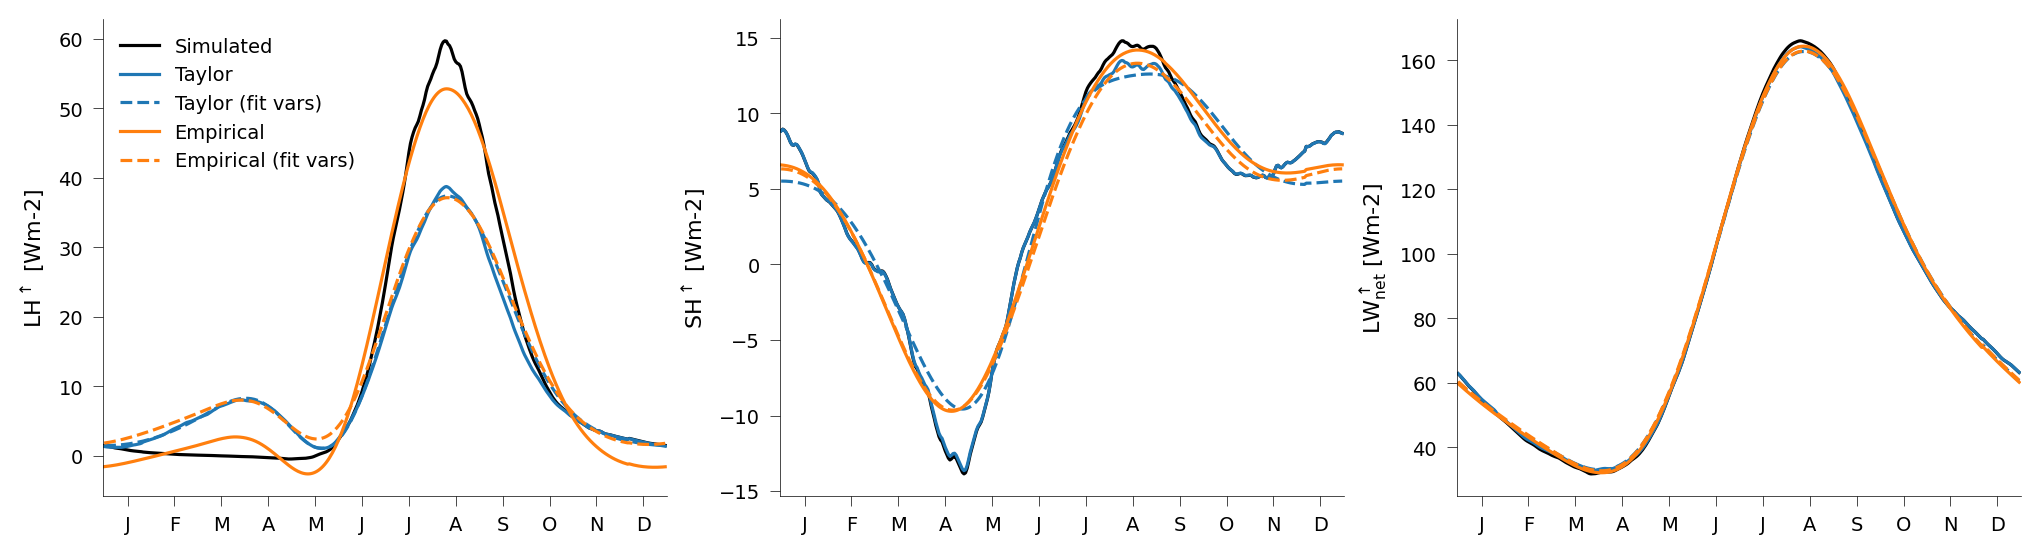

In [27]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=False)
fig_resize(fig, width['two_col'] / 2 * 3 * 1.5)

for i, key in enumerate(flux_approx.keys()):
    ax[i].set_ylabel(utils.style_map[key][2] + " [Wm-2]")
    for key2 in style_map_approx:
        ax[i].plot(ds.time, flux_approx[key][key2], color=style_map_approx[key2][0],
                   linestyle=style_map_approx[key2][1],
                   label=style_map_approx[key2][2])
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_xlim(utils.ax_lims_time)
update_linewidth(fig)
ax[0].legend()
plt.show()